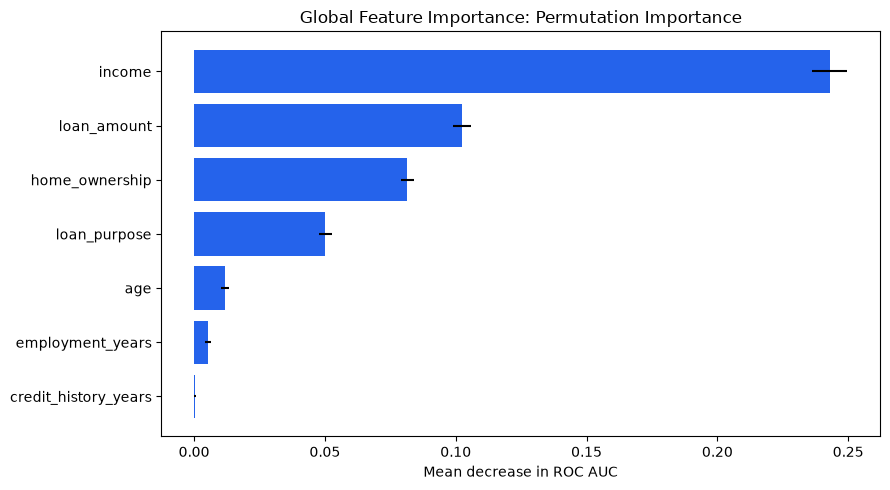

,feature,importance
8,cat__home_ownership_RENT,0.238211
11,cat__loan_purpose_HOMEIMPROVEMENT,0.116869
1,num__income,0.112077
7,cat__home_ownership_OWN,0.097802
3,num__loan_amount,0.083811
14,cat__loan_purpose_VENTURE,0.054323
5,cat__home_ownership_MORTGAGE,0.052690
12,cat__loan_purpose_MEDICAL,0.047671
9,cat__loan_purpose_DEBTCONSOLIDATION,0.039613
10,cat__loan_purpose_EDUCATION,0.033375


Predicted default probability: 0.115


,feature,original_value,baseline_probability,probability_after_replacement,probability_change
4,loan_amount,5400,0.115237,0.168802,0.053564
1,income,63533,0.115237,0.066303,-0.048934
2,employment_years,0.0,0.115237,0.077046,-0.038191
5,loan_purpose,PERSONAL,0.115237,0.111491,-0.003746
0,age,29,0.115237,0.111968,-0.003269
6,credit_history_years,7,0.115237,0.117095,0.001858
3,home_ownership,RENT,0.115237,0.115237,0.000000


In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split


# Load the same test split used during model comparison.
df = pd.read_csv("../data/processed/model_data.csv")
X = df.drop("default", axis=1)
y = df["default"]

_, X_test, _, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = joblib.load("../models/best_model.pkl")

# Global importance: measure how much shuffling each original feature hurts ROC AUC.
permutation = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

plt.figure(figsize=(9, 5))
plt.barh(
    permutation_importance_df["feature"].head(10)[::-1],
    permutation_importance_df["importance_mean"].head(10)[::-1],
    xerr=permutation_importance_df["importance_std"].head(10)[::-1],
    color="#2563eb"
)
plt.xlabel("Mean decrease in ROC AUC")
plt.title("Global Feature Importance: Permutation Importance")
plt.tight_layout()
plt.show()

permutation_importance_df


# Model-level importance after one-hot encoding.
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]
feature_names = preprocessor.get_feature_names_out()

if hasattr(classifier, "feature_importances_"):
    transformed_importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": classifier.feature_importances_
        })
        .sort_values("importance", ascending=False)
    )
    display(transformed_importance_df.head(15))


# Local explanation: compare one applicant's probability with and without each feature.
sample = X_test.iloc[[0]].copy()
base_probability = model.predict_proba(sample)[0, 1]
local_rows = []

for feature in X.columns:
    changed_sample = sample.copy()
    changed_sample[feature] = X_test[feature].median() if pd.api.types.is_numeric_dtype(X_test[feature]) else X_test[feature].mode().iloc[0]
    changed_probability = model.predict_proba(changed_sample)[0, 1]
    local_rows.append({
        "feature": feature,
        "original_value": sample.iloc[0][feature],
        "baseline_probability": base_probability,
        "probability_after_replacement": changed_probability,
        "probability_change": changed_probability - base_probability
    })

local_explanation_df = (
    pd.DataFrame(local_rows)
    .sort_values("probability_change", key=lambda values: values.abs(), ascending=False)
)

print(f"Predicted default probability: {base_probability:.3f}")
display(local_explanation_df)
